# **Fake News Detection in Spanish using Deep Learning**
JUAN ACUÑA

GUILLERMO HERNANDEZ

EMANUEL WILCHEZ

1. **DESCARGA DATA SET- CONJUNTO**

In [1]:
# ═══════════════════════════════════════════════════════════════════════════════
# COMBINACIÓN DE DATASETS – Fake News en Español
# ───────────────────────────────────────────────────────────────────────────────
# Fuente 1 │ FakeNewsCorpusSpanish (GitHub jpposadas)
#           │ train.xlsx (676) + development.xlsx (295) + test.xlsx (572)
# Fuente 2 │ Guillermo (guillermoezquer/fakenews-espaol) │ TSV │ Win-1252
# Fuente 3 │ Arsenii   (arseniitretiakov/noticias-falsas-en-espaol) │ CSV
# ═══════════════════════════════════════════════════════════════════════════════

import kagglehub, os, glob, pandas as pd
from pathlib import Path

frames = []

# ─── FUENTE 1 – FakeNewsCorpusSpanish (GitHub) ───────────────────────────────
print("=" * 60)
print("FUENTE 1 – Descargando FakeNewsCorpusSpanish desde GitHub...")

DATA_DIR = Path("data/raw")
DATA_DIR.mkdir(parents=True, exist_ok=True)

!wget -q -O data/raw/train.xlsx       https://raw.githubusercontent.com/jpposadas/FakeNewsCorpusSpanish/master/train.xlsx
!wget -q -O data/raw/development.xlsx https://raw.githubusercontent.com/jpposadas/FakeNewsCorpusSpanish/master/development.xlsx
!wget -q -O data/raw/test.xlsx        https://raw.githubusercontent.com/jpposadas/FakeNewsCorpusSpanish/master/test.xlsx

total_f1 = 0
for file in sorted(DATA_DIR.glob("*.xlsx")):
    df_tmp = pd.read_excel(file)
    df_tmp.columns = [c.lower() for c in df_tmp.columns]

    lbl = df_tmp["category"]
    if lbl.dtype == object:
        lbl = lbl.str.strip().map({"Fake": 1, "True": 0, "fake": 1, "true": 0})
    else:
        lbl = lbl.map({False: 1, True: 0})

    df_tmp["label"]  = lbl.astype(int)
    df_tmp["title"]  = df_tmp["headline"].fillna("")
    df_tmp["text"]   = df_tmp["text"].fillna("")
    df_tmp["source"] = file.stem

    sub = df_tmp[["title","text","label","source"]].dropna(subset=["label"])
    frames.append(sub)
    total_f1 += len(sub)
    print(f"  {file.name:<25} {len(sub):>4} noticias │ Reales: {(sub.label==0).sum()} │ Falsas: {(sub.label==1).sum()}")

print(f"  {'SUBTOTAL':<25} {total_f1:>4} noticias")

# ─── FUENTE 2 – Guillermo (Kaggle, TSV Windows-1252) ─────────────────────────
print()
print("=" * 60)
print("FUENTE 2 – Descargando Guillermo desde Kaggle...")

path_g = kagglehub.dataset_download("guillermoezquer/fakenews-espaol")
print(f"  Path: {path_g}")
print(f"  Archivos: {os.listdir(path_g)}")

# Buscar el .txt o .tsv descargado
txt_files = glob.glob(os.path.join(path_g, "*.txt")) + glob.glob(os.path.join(path_g, "*.tsv"))
assert len(txt_files) > 0, f"❌ No se encontró archivo .txt/.tsv en {path_g}. Archivos: {os.listdir(path_g)}"

df2_raw = pd.read_csv(
    txt_files[0],
    sep="\t",
    encoding="windows-1252",
    on_bad_lines="skip",
    names=["Class","Text"],
    header=0,
)
df2_raw = df2_raw.dropna(subset=["Class","Text"])
df2_raw["label"]  = df2_raw["Class"].map({True: 0, False: 1})
df2_raw = df2_raw.dropna(subset=["label"])
df2_raw["label"]  = df2_raw["label"].astype(int)
df2_raw["title"]  = df2_raw["Text"].str.slice(0, 80)
df2_raw["text"]   = df2_raw["Text"]
df2_raw["source"] = "guillermo_txt"

sub2 = df2_raw[["title","text","label","source"]].reset_index(drop=True)
frames.append(sub2)
print(f"  {txt_files[0].split('/')[-1]:<25} {len(sub2):>4} noticias │ Reales: {(sub2.label==0).sum()} │ Falsas: {(sub2.label==1).sum()}")
print(f"  Muestra (verificar acentos): {sub2.text.iloc[0][:80]}")

# ─── FUENTE 3 – Arsenii (Kaggle) ─────────────────────────────────────────────
print()
print("=" * 60)
print("FUENTE 3 – Descargando Arsenii desde Kaggle...")

path_a = kagglehub.dataset_download("arseniitretiakov/noticias-falsas-en-espaol")
print(f"  Path: {path_a}")
print(f"  Archivos: {os.listdir(path_a)}")

arsenii_frames = []

# onlyfakes1000.csv → solo columna 'text', todas falsas (1)
tmp = pd.read_csv(os.path.join(path_a, "onlyfakes1000.csv"), encoding="utf-8", on_bad_lines="skip")
tmp["label"]  = 1
tmp["title"]  = tmp["text"].str.slice(0, 80)
tmp["source"] = "arsenii_csv"
arsenii_frames.append(tmp[["title","text","label","source"]])
print(f"  onlyfakes1000.csv         {len(tmp):>4} noticias │ label=1 (falsas)")

# onlytrue1000.csv → solo columna 'text', todas reales (0)
tmp = pd.read_csv(os.path.join(path_a, "onlytrue1000.csv"), encoding="utf-8", on_bad_lines="skip")
tmp["label"]  = 0
tmp["title"]  = tmp["text"].str.slice(0, 80)
tmp["source"] = "arsenii_csv"
arsenii_frames.append(tmp[["title","text","label","source"]])
print(f"  onlytrue1000.csv          {len(tmp):>4} noticias │ label=0 (reales)")

# train.csv → tiene columnas 'title','text','label' — usarla directo
tmp = pd.read_csv(os.path.join(path_a, "train.csv"), encoding="utf-8", on_bad_lines="skip")
tmp["title"]  = tmp["title"].fillna(tmp["text"].str.slice(0, 80))
tmp["source"] = "arsenii_csv"
arsenii_frames.append(tmp[["title","text","label","source"]])
print(f"  train.csv                 {len(tmp):>4} noticias │ label desde columna")

# test.csv → tiene 'title','text' pero SIN label — descartar
print(f"  test.csv                  descartado (sin columna label)")

# fakes1000.csv → columnas 'class','Text' — class=True significa real (nombre confuso)
tmp = pd.read_csv(os.path.join(path_a, "fakes1000.csv"), encoding="utf-8", on_bad_lines="skip")
tmp = tmp.rename(columns={"Text": "text"})
tmp["label"]  = tmp["class"].map({True: 0, False: 1, "True": 0, "False": 1})
tmp["title"]  = tmp["text"].str.slice(0, 80)
tmp["source"] = "arsenii_csv"
arsenii_frames.append(tmp[["title","text","label","source"]])
print(f"  fakes1000.csv             {len(tmp):>4} noticias │ label desde columna class")

df3_out = pd.concat(arsenii_frames, ignore_index=True)
df3_out = df3_out.dropna(subset=["label","text"])
df3_out = df3_out.drop_duplicates(subset=["text"]).reset_index(drop=True)
df3_out["label"] = df3_out["label"].astype(int)

frames.append(df3_out)
print(f"  {'SUBTOTAL Arsenii':<25} {len(df3_out):>4} noticias │ Reales: {(df3_out.label==0).sum()} │ Falsas: {(df3_out.label==1).sum()}")

# ─── UNIÓN FINAL ──────────────────────────────────────────────────────────────
print()
print("=" * 60)
df    = pd.concat(frames, ignore_index=True)
antes = len(df)
df    = df.drop_duplicates(subset=["text"]).reset_index(drop=True)
df    = df[df["text"].str.len() >= 30].reset_index(drop=True)

print(f"  FakeNewsCorpusSpanish (GitHub) : {total_f1:>5}")
print(f"  Guillermo txt (Kaggle)         : {len(sub2):>5}")
print(f"  Arsenii CSV   (Kaggle)         : {len(df3_out):>5}")
print(f"  Duplicados eliminados          : {antes - len(df):>5}")
print(f"  ─────────────────────────────────────")
print(f"  TOTAL FINAL                    : {len(df):>5} noticias")
print(f"  Reales  (0)                    : {(df.label==0).sum():>5}")
print(f"  Falsas  (1)                    : {(df.label==1).sum():>5}")
print()

# 2 ejemplos de cada fuente
for src in df["source"].unique():
    sub = df[df["source"] == src]
    print(f"──── {src}  ({len(sub)} noticias) ────")
    for _, row in sub.sample(min(2, len(sub)), random_state=42).iterrows():
        print(f"  [{'REAL' if row.label==0 else 'FALSA'}] {row.title[:90]}")
    print()

print("✅ df listo — continúa con la celda de EDA")

FUENTE 1 – Descargando FakeNewsCorpusSpanish desde GitHub...
  development.xlsx           295 noticias │ Reales: 153 │ Falsas: 142
  test.xlsx                  572 noticias │ Reales: 286 │ Falsas: 286
  train.xlsx                 676 noticias │ Reales: 338 │ Falsas: 338
  SUBTOTAL                  1543 noticias

FUENTE 2 – Descargando Guillermo desde Kaggle...


100%|██████████| 1.54M/1.54M [00:00<00:00, 2.86MB/s]

Extracting files...


  Path: /root/.cache/kagglehub/datasets/guillermoezquer/fakenews-espaol/versions/1
  Archivos: ['fakeNews.txt']
  fakeNews.txt              3568 noticias │ Reales: 1829 │ Falsas: 1739
  Muestra (verificar acentos): Algunas de las voces extremistas más conocidas de EE.UU., cuentas asociadas con 

FUENTE 3 – Descargando Arsenii desde Kaggle...


100%|██████████| 618k/618k [00:00<00:00, 1.36MB/s]

Extracting files...


  Path: /root/.cache/kagglehub/datasets/arseniitretiakov/noticias-falsas-en-espaol/versions/1
  Archivos: ['onlyfakes1000.csv', 'fakes1000.csv', 'train.csv', 'test.csv', 'onlytrue1000.csv']
  onlyfakes1000.csv         1000 noticias │ label=1 (falsas)
  onlytrue1000.csv          1000 noticias │ label=0 (reales)
  train.csv                 1600 noticias │ label desde columna
  test.csv                  descartado (sin columna label)
  fakes1000.csv             2000 noticias │ label desde columna class
  SUBTOTAL Arsenii          1958 noticias │ Reales: 993 │ Falsas: 965

  FakeNewsCorpusSpanish (GitHub) :  1543
  Guillermo txt (Kaggle)         :  3568
  Arsenii CSV   (Kaggle)         :  1958
  Duplicados eliminados          :  1364
  ─────────────────────────────────────
  TOTAL FINAL                    :  5705 noticias
  Reales  (0)                    :  3047
  Falsas  (1)                    :  2658

──── development  (294 noticias) ────
  [FALSA] Hay que quitarles a las mujeres el voto

2. **PREPROCESAMIENTO**

Dataset mezclado aleatoriamente: 5705 noticias


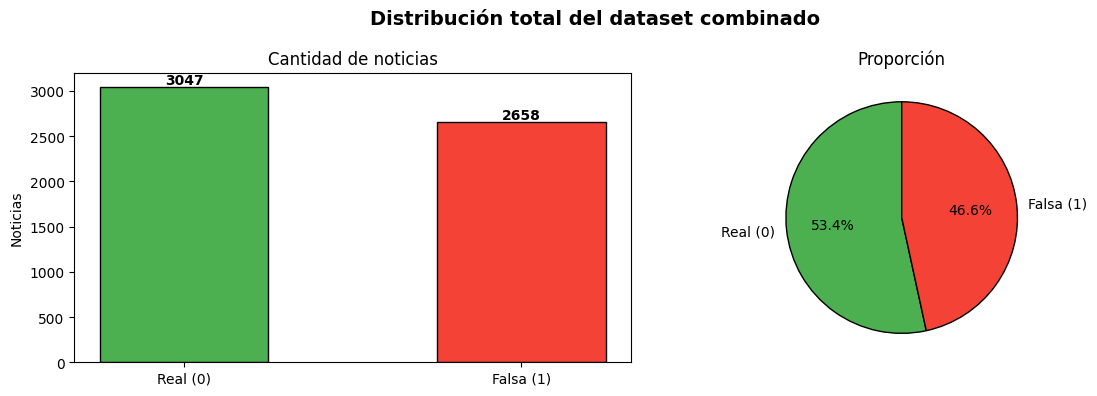


  Reales  (0):  3047  (53.4%)
  Falsas  (1):  2658  (46.6%)
  Total       :  5705

─────────────────────────────────────────────
  Split           Muestras   Reales   Falsas
─────────────────────────────────────────────
  Train  (70%)     3993     2133     1860
  Val    (15%)      856      457      399
  Test   (15%)      856      457      399
─────────────────────────────────────────────
  TOTAL             5705     3047     2658

════════════════════════════════════════════════════════════
EJEMPLOS DEL DATASET
════════════════════════════════════════════════════════════

──── TRAIN ────
  [FALSA] Traduzco al Nazi Fascista Golpista rogertorrent Cuando consigamos la República y [SEP] Traduzco al Nazi Fascista Golpist...
  [REAL] "Casa Blanca": el presidente de México, Enrique Peña Nieto, pide disculpas por e [SEP] "Casa Blanca": el presidente de M...

──── VAL ────
  [REAL] La desaceleración económica y la normalización del mercado inmobiliario en Espa [SEP] La desaceleración económic

In [2]:

# PREPROCESAMIENTO

import re, unicodedata
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# ─── 1. Limpieza de texto ─────────────────────────────────────────────────────
def clean_text(text):
    text = unicodedata.normalize("NFC", str(text))       # normalizar acentos
    text = re.sub(r"http\S+|www\S+", "", text)           # eliminar URLs
    text = re.sub(r"@\w+", "", text)                     # eliminar menciones
    text = re.sub(r"#\w+", "", text)                     # eliminar hashtags
    text = re.sub(r"\s+", " ", text).strip()             # colapsar espacios
    return text

df["title"]    = df["title"].apply(clean_text)
df["text"]     = df["text"].apply(clean_text)
df["combined"] = df["title"] + " [SEP] " + df["text"]

# ─── 2. Shuffle aleatorio del dataset completo ────────────────────────────────
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
print(f"Dataset mezclado aleatoriamente: {len(df)} noticias")

# ─── 3. Gráfica: distribución total real vs falsa ────────────────────────────
conteo   = df["label"].value_counts().sort_index()
etiquetas = ["Real (0)", "Falsa (1)"]
colores   = ["#4CAF50", "#F44336"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Distribución total del dataset combinado", fontsize=14, fontweight="bold")

# Barras
axes[0].bar(etiquetas, conteo.values, color=colores, edgecolor="black", width=0.5)
axes[0].set_title("Cantidad de noticias")
axes[0].set_ylabel("Noticias")
for i, v in enumerate(conteo.values):
    axes[0].text(i, v + 30, str(v), ha="center", fontweight="bold")

# Pie
axes[1].pie(
    conteo.values,
    labels=etiquetas,
    colors=colores,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor": "black"},
)
axes[1].set_title("Proporción")

plt.tight_layout()
plt.show()

print(f"\n  Reales  (0): {conteo[0]:>5}  ({conteo[0]/len(df)*100:.1f}%)")
print(f"  Falsas  (1): {conteo[1]:>5}  ({conteo[1]/len(df)*100:.1f}%)")
print(f"  Total       : {len(df):>5}")

# ─── 4. Split 70 / 15 / 15 ───────────────────────────────────────────────────
X = df["combined"].values
y = df["label"].values

# Primero 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Luego el 30% temp → 50/50 → 15% val + 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"\n{'─'*45}")
print(f"  Split           Muestras   Reales   Falsas")
print(f"{'─'*45}")
for nombre, yy in [("Train  (70%)", y_train), ("Val    (15%)", y_val), ("Test   (15%)", y_test)]:
    print(f"  {nombre}   {len(yy):>6}   {(yy==0).sum():>6}   {(yy==1).sum():>6}")
print(f"{'─'*45}")
print(f"  TOTAL           {len(y):>6}   {(y==0).sum():>6}   {(y==1).sum():>6}")

# ─── 5. Ejemplos de cada split ───────────────────────────────────────────────
print(f"\n{'═'*60}")
print("EJEMPLOS DEL DATASET")
print(f"{'═'*60}")

indices = {
    "TRAIN": (X_train, y_train),
    "VAL"  : (X_val,   y_val),
    "TEST" : (X_test,  y_test),
}

for split_name, (X_s, y_s) in indices.items():
    print(f"\n──── {split_name} ────")
    for i in range(2):
        label_str = "REAL" if y_s[i] == 0 else "FALSA"
        texto     = X_s[i][:120].replace("\n", " ")
        print(f"  [{label_str}] {texto}...")

**MODELO 1 BETO- COMPARACION MODELO BASE**

Dispositivo : cuda
Modelo      : dccuchile/bert-base-spanish-wwm-cased

Cargando tokenizer...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/364 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...


Epoch 3 │ train_loss: 0.0953 │ val_loss: 0.3632 │ val_acc: 0.9112 │ val_f1: 0.9107 │ val_auc: 0.9641
  ✅ Mejor modelo guardado (val_f1=0.9107)


Epoch 4/5:   0%|          | 0/250 [00:00<?, ?it/s]


Epoch 4 │ train_loss: 0.0239 │ val_loss: 0.4913 │ val_acc: 0.9147 │ val_f1: 0.9144 │ val_auc: 0.9653
  ✅ Mejor modelo guardado (val_f1=0.9144)


Epoch 5/5:   0%|          | 0/250 [00:00<?, ?it/s]


Epoch 5 │ train_loss: 0.0058 │ val_loss: 0.4970 │ val_acc: 0.9124 │ val_f1: 0.9118 │ val_auc: 0.9640

════════════════════════════════════════════════════════════
EVALUACIÓN FINAL BETO – TEST SET
════════════════════════════════════════════════════════════
  Accuracy base (sin FT) : 0.5023  (50.2%)
  Accuracy fine-tuned    : 0.9019  (90.2%)
  Mejora                 : +40.0 puntos porcentuales
  ─────────────────────────────────────────────────────
  F1 Macro  : 0.9013
  ROC-AUC   : 0.9631


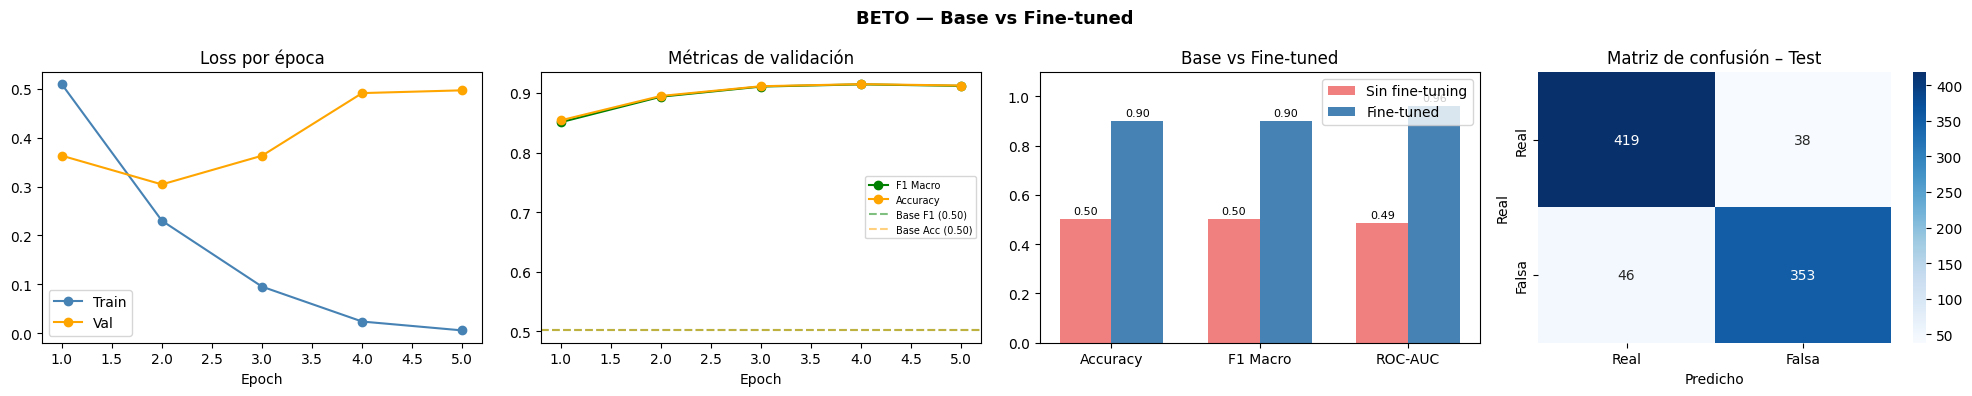

In [3]:
# ═══════════════════════════════════════════════════════════════════════════════
# BETO – BASE vs FINE-TUNED
# dccuchile/bert-base-spanish-wwm-cased | Universidad de Chile
# ═══════════════════════════════════════════════════════════════════════════════

import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    BertTokenizerFast,
    BertForSequenceClassification,
    get_linear_schedule_with_warmup,
)
from torch.optim import AdamW
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_NAME = "dccuchile/bert-base-spanish-wwm-cased"
MAX_LEN    = 256
BATCH_SIZE = 16
EPOCHS     = 5
LR         = 2e-5

print(f"Dispositivo : {DEVICE}")
print(f"Modelo      : {MODEL_NAME}")

# ─── Dataset ─────────────────────────────────────────────────────────────────
class FakeNewsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer):
        self.encodings = tokenizer(
            list(texts),
            max_length=MAX_LEN,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        self.labels = torch.tensor(list(labels), dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids":      self.encodings["input_ids"][idx],
            "attention_mask": self.encodings["attention_mask"][idx],
            "token_type_ids": self.encodings["token_type_ids"][idx],
            "labels":         self.labels[idx],
        }

# ─── Tokenizer y datasets ────────────────────────────────────────────────────
print("\nCargando tokenizer...")
tokenizer = BertTokenizerFast.from_pretrained(MODEL_NAME)

print("Tokenizando splits...")
train_dataset = FakeNewsDataset(X_train, y_train, tokenizer)
val_dataset   = FakeNewsDataset(X_val,   y_val,   tokenizer)
test_dataset  = FakeNewsDataset(X_test,  y_test,  tokenizer)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE)

# ─── Función de evaluación ────────────────────────────────────────────────────
def evaluate_beto(model, loader):
    model.eval()
    all_preds, all_probs, all_labels = [], [], []
    total_loss = 0
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            token_type_ids = batch["token_type_ids"].to(DEVICE)
            labels         = batch["labels"].to(DEVICE)
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                token_type_ids=token_type_ids,
                labels=labels,
            )
            total_loss += outputs.loss.item()
            probs  = torch.softmax(outputs.logits, dim=1)[:, 1]
            preds  = torch.argmax(outputs.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc  = accuracy_score(all_labels, all_preds)
    f1   = f1_score(all_labels, all_preds, average="macro")
    auc  = roc_auc_score(all_labels, all_probs)
    return avg_loss, acc, f1, auc, all_preds, all_probs, all_labels

# ─── Cargar modelo ────────────────────────────────────────────────────────────
print("\nCargando modelo BETO...")
model_beto = BertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    hidden_dropout_prob=0.1,
    attention_probs_dropout_prob=0.1,
)
model_beto.to(DEVICE)

total_params     = sum(p.numel() for p in model_beto.parameters())
trainable_params = sum(p.numel() for p in model_beto.parameters() if p.requires_grad)
print(f"  Parámetros totales     : {total_params:,}")
print(f"  Parámetros entrenables : {trainable_params:,}")

# ─── ACCURACY BASE (sin fine-tuning) ─────────────────────────────────────────
print("\n" + "═" * 60)
print("ACCURACY BASE – BETO SIN fine-tuning")
print("═" * 60)

_, base_acc, base_f1, base_auc, _, _, _ = evaluate_beto(model_beto, test_loader)
print(f"  Accuracy  : {base_acc:.4f}  ({base_acc*100:.1f}%)")
print(f"  F1 Macro  : {base_f1:.4f}")
print(f"  ROC-AUC   : {base_auc:.4f}")
print(f"  → Referencia para medir la mejora del fine-tuning")

# ─── Optimizador y scheduler ─────────────────────────────────────────────────
optimizer = AdamW(model_beto.parameters(), lr=LR, weight_decay=0.01)

total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * 0.1)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

# ─── Loop de entrenamiento ────────────────────────────────────────────────────
history_beto = {"train_loss": [], "val_loss": [], "val_acc": [], "val_f1": [], "val_auc": []}
best_val_f1  = 0
no_improve   = 0
PATIENCE     = 2

print("\n" + "═" * 60)
print("ENTRENAMIENTO BETO")
print("═" * 60)

for epoch in range(1, EPOCHS + 1):
    model_beto.train()
    total_train_loss = 0

    loop = tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS}")
    for batch in loop:
        input_ids      = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        token_type_ids = batch["token_type_ids"].to(DEVICE)
        labels         = batch["labels"].to(DEVICE)

        optimizer.zero_grad()
        outputs = model_beto(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
            labels=labels,
        )
        outputs.loss.backward()
        torch.nn.utils.clip_grad_norm_(model_beto.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_train_loss += outputs.loss.item()
        loop.set_postfix(loss=outputs.loss.item())

    avg_train_loss = total_train_loss / len(train_loader)
    val_loss, val_acc, val_f1, val_auc, _, _, _ = evaluate_beto(model_beto, val_loader)

    history_beto["train_loss"].append(avg_train_loss)
    history_beto["val_loss"].append(val_loss)
    history_beto["val_acc"].append(val_acc)
    history_beto["val_f1"].append(val_f1)
    history_beto["val_auc"].append(val_auc)

    print(f"\nEpoch {epoch} │ train_loss: {avg_train_loss:.4f} │ "
          f"val_loss: {val_loss:.4f} │ val_acc: {val_acc:.4f} │ "
          f"val_f1: {val_f1:.4f} │ val_auc: {val_auc:.4f}")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model_beto.state_dict(), "beto_best.pt")
        print(f"  ✅ Mejor modelo guardado (val_f1={best_val_f1:.4f})")
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f"  ⏹ Early stopping en epoch {epoch}")
            break

# ─── Evaluación final en TEST ─────────────────────────────────────────────────
print("\n" + "═" * 60)
print("EVALUACIÓN FINAL BETO – TEST SET")
print("═" * 60)

model_beto.load_state_dict(torch.load("beto_best.pt"))
_, test_acc, test_f1, test_auc, test_preds, test_probs, test_labels = evaluate_beto(model_beto, test_loader)

print(f"  Accuracy base (sin FT) : {base_acc:.4f}  ({base_acc*100:.1f}%)")
print(f"  Accuracy fine-tuned    : {test_acc:.4f}  ({test_acc*100:.1f}%)")
print(f"  Mejora                 : +{(test_acc - base_acc)*100:.1f} puntos porcentuales")
print(f"  ─────────────────────────────────────────────────────")
print(f"  F1 Macro  : {test_f1:.4f}")
print(f"  ROC-AUC   : {test_auc:.4f}")

beto_results = {
    "name":     "BETO (Baseline)",
    "acc":      test_acc,
    "f1":       test_f1,
    "auc":      test_auc,
    "preds":    test_preds,
    "probs":    test_probs,
    "labels":   test_labels,
    "history":  history_beto,
    "base_acc": base_acc,
    "base_f1":  base_f1,
    "base_auc": base_auc,
}

# ─── Gráficas: Base vs Fine-tuned ────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
fig.suptitle("BETO — Base vs Fine-tuned", fontsize=13, fontweight="bold")

epochs_ran = range(1, len(history_beto["train_loss"]) + 1)

# Loss
axes[0].plot(epochs_ran, history_beto["train_loss"], label="Train", marker="o", color="steelblue")
axes[0].plot(epochs_ran, history_beto["val_loss"],   label="Val",   marker="o", color="orange")
axes[0].set_title("Loss por época")
axes[0].set_xlabel("Epoch")
axes[0].legend()

# F1 y Accuracy con línea base
axes[1].plot(epochs_ran, history_beto["val_f1"],  label="F1 Macro", marker="o", color="green")
axes[1].plot(epochs_ran, history_beto["val_acc"], label="Accuracy", marker="o", color="orange")
axes[1].axhline(y=base_f1,  color="green",  linestyle="--", alpha=0.5, label=f"Base F1 ({base_f1:.2f})")
axes[1].axhline(y=base_acc, color="orange", linestyle="--", alpha=0.5, label=f"Base Acc ({base_acc:.2f})")
axes[1].set_title("Métricas de validación")
axes[1].set_xlabel("Epoch")
axes[1].legend(fontsize=7)

# Barras comparativas Base vs Fine-tuned
metricas  = ["Accuracy", "F1 Macro", "ROC-AUC"]
base_vals = [base_acc,  base_f1,  base_auc]
ft_vals   = [test_acc,  test_f1,  test_auc]
x         = range(len(metricas))
width     = 0.35

axes[2].bar([i - width/2 for i in x], base_vals, width, label="Sin fine-tuning", color="lightcoral")
axes[2].bar([i + width/2 for i in x], ft_vals,   width, label="Fine-tuned",      color="steelblue")
axes[2].set_xticks(list(x))
axes[2].set_xticklabels(metricas)
axes[2].set_ylim(0, 1.1)
axes[2].set_title("Base vs Fine-tuned")
axes[2].legend()
for i, (b, f) in enumerate(zip(base_vals, ft_vals)):
    axes[2].text(i - width/2, b + 0.02, f"{b:.2f}", ha="center", fontsize=8)
    axes[2].text(i + width/2, f + 0.02, f"{f:.2f}", ha="center", fontsize=8)

# Matriz de confusión
cm = confusion_matrix(test_labels, test_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Real","Falsa"],
            yticklabels=["Real","Falsa"], ax=axes[3])
axes[3].set_title("Matriz de confusión – Test")
axes[3].set_ylabel("Real")
axes[3].set_xlabel("Predicho")

plt.tight_layout()
plt.show()

**MODELO 2 RoBERTa - COMPARACION MODELO BASE**


Dispositivo : cuda
Modelo      : bertin-project/bertin-roberta-base-spanish

Cargando tokenizer RoBERTa-es...


config.json:   0%|          | 0.00/674 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...


Epoch 3 │ train_loss: 0.1124 │ val_loss: 0.4570 │ val_acc: 0.9007 │ val_f1: 0.9005 │ val_auc: 0.9596
  ✅ Mejor modelo guardado (val_f1=0.9005)


Epoch 4/5:   0%|          | 0/250 [00:00<?, ?it/s]


Epoch 4 │ train_loss: 0.0463 │ val_loss: 0.3766 │ val_acc: 0.9217 │ val_f1: 0.9211 │ val_auc: 0.9645
  ✅ Mejor modelo guardado (val_f1=0.9211)


Epoch 5/5:   0%|          | 0/250 [00:00<?, ?it/s]


Epoch 5 │ train_loss: 0.0223 │ val_loss: 0.4651 │ val_acc: 0.9159 │ val_f1: 0.9156 │ val_auc: 0.9649

════════════════════════════════════════════════════════════
EVALUACIÓN FINAL RoBERTa-es – TEST SET
════════════════════════════════════════════════════════════
  Accuracy base (sin FT) : 0.5315  (53.2%)
  Accuracy fine-tuned    : 0.9089  (90.9%)
  Mejora                 : +37.7 puntos porcentuales
  ─────────────────────────────────────────
  F1 Macro  : 0.9078
  ROC-AUC   : 0.9472


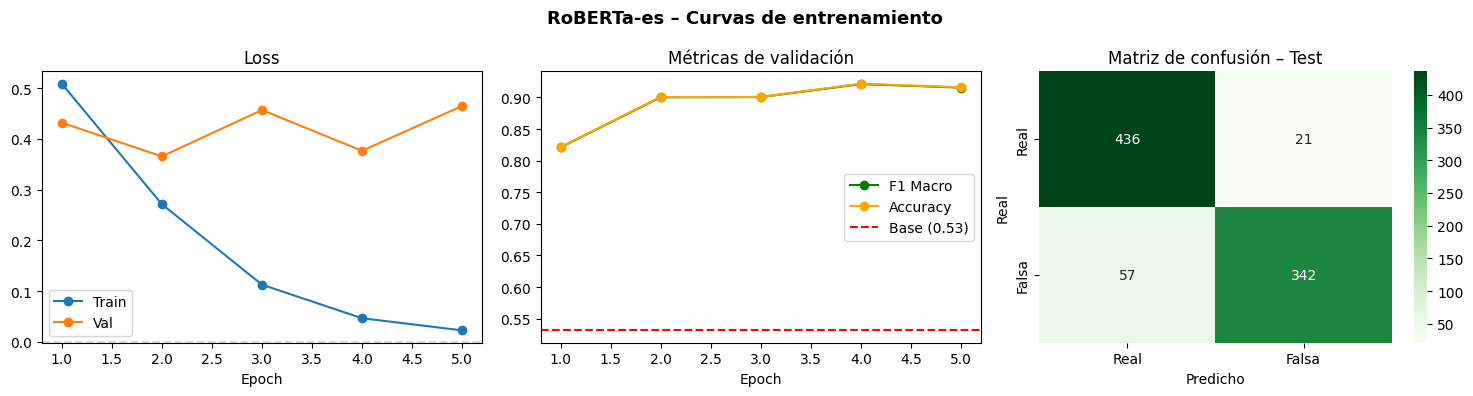

In [4]:
# ═══════════════════════════════════════════════════════════════════════════════
# MODELO MEJORADO – RoBERTa-es
# PlanTL-GOB-ES/roberta-base-bne | Plan de Tecnologías del Lenguaje, España
# Mejoras sobre BETO:
#   · +100GB texto español vs 3GB de BETO
#   · Sin NSP — demostró ser innecesaria
#   · Dynamic masking — máscaras diferentes cada época
#   · Vocabulario 50k subwords vs 31k de BETO
# ═══════════════════════════════════════════════════════════════════════════════

import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
)
from torch.optim import AdamW
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

DEVICE          = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ROBERTA_MODEL = "bertin-project/bertin-roberta-base-spanish"
MAX_LEN         = 256
BATCH_SIZE      = 16
EPOCHS          = 5
LR              = 2e-5

print(f"Dispositivo : {DEVICE}")
print(f"Modelo      : {ROBERTA_MODEL}")

# ─── Dataset ─────────────────────────────────────────────────────────────────
class RobertaDataset(Dataset):
    def __init__(self, texts, labels, tokenizer):
        self.encodings = tokenizer(
            list(texts),
            max_length=MAX_LEN,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        self.labels = torch.tensor(list(labels), dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids":      self.encodings["input_ids"][idx],
            "attention_mask": self.encodings["attention_mask"][idx],
            "labels":         self.labels[idx],
        }

# ─── Tokenizer y datasets ────────────────────────────────────────────────────
print("\nCargando tokenizer RoBERTa-es...")
tokenizer_roberta = AutoTokenizer.from_pretrained(ROBERTA_MODEL)

print("Tokenizando splits...")
train_ds_r = RobertaDataset(X_train, y_train, tokenizer_roberta)
val_ds_r   = RobertaDataset(X_val,   y_val,   tokenizer_roberta)
test_ds_r  = RobertaDataset(X_test,  y_test,  tokenizer_roberta)

train_dl_r = DataLoader(train_ds_r, batch_size=BATCH_SIZE, shuffle=True)
val_dl_r   = DataLoader(val_ds_r,   batch_size=BATCH_SIZE)
test_dl_r  = DataLoader(test_ds_r,  batch_size=BATCH_SIZE)

print(f"  Train batches : {len(train_dl_r)}")
print(f"  Val   batches : {len(val_dl_r)}")
print(f"  Test  batches : {len(test_dl_r)}")

# ─── Accuracy BASE (sin fine-tuning) ─────────────────────────────────────────
print("\n" + "═" * 60)
print("ACCURACY BASE – RoBERTa-es SIN fine-tuning")
print("═" * 60)

model_roberta = AutoModelForSequenceClassification.from_pretrained(
    ROBERTA_MODEL, num_labels=2
)
model_roberta.to(DEVICE)

model_roberta.eval()
base_preds, base_labels = [], []
with torch.no_grad():
    for batch in tqdm(test_dl_r, desc="Evaluando base"):
        input_ids      = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels         = batch["labels"].to(DEVICE)
        outputs = model_roberta(input_ids=input_ids, attention_mask=attention_mask)
        preds   = torch.argmax(outputs.logits, dim=1)
        base_preds.extend(preds.cpu().numpy())
        base_labels.extend(labels.cpu().numpy())

base_acc = accuracy_score(base_labels, base_preds)
base_f1  = f1_score(base_labels, base_preds, average="macro")
print(f"  Accuracy SIN fine-tuning : {base_acc:.4f}  ({base_acc*100:.1f}%)")
print(f"  F1 Macro SIN fine-tuning : {base_f1:.4f}")
print(f"  → Referencia para medir la mejora del fine-tuning")

# ─── Optimizador y scheduler ─────────────────────────────────────────────────
optimizer_r = AdamW(model_roberta.parameters(), lr=LR, weight_decay=0.01)

total_steps  = len(train_dl_r) * EPOCHS
warmup_steps = int(total_steps * 0.1)

scheduler_r = get_linear_schedule_with_warmup(
    optimizer_r,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

print(f"\n  Total steps  : {total_steps}")
print(f"  Warmup steps : {warmup_steps}")

# ─── Función de evaluación ────────────────────────────────────────────────────
def evaluate_roberta(model, loader):
    model.eval()
    all_preds, all_probs, all_labels = [], [], []
    total_loss = 0
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            labels         = batch["labels"].to(DEVICE)
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels,
            )
            total_loss += outputs.loss.item()
            probs  = torch.softmax(outputs.logits, dim=1)[:, 1]
            preds  = torch.argmax(outputs.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc  = accuracy_score(all_labels, all_preds)
    f1   = f1_score(all_labels, all_preds, average="macro")
    auc  = roc_auc_score(all_labels, all_probs)
    return avg_loss, acc, f1, auc, all_preds, all_probs, all_labels

# ─── Loop de entrenamiento ────────────────────────────────────────────────────
history_roberta = {"train_loss": [], "val_loss": [], "val_acc": [], "val_f1": [], "val_auc": []}
best_val_f1     = 0
no_improve      = 0
PATIENCE        = 2

print("\n" + "═" * 60)
print("ENTRENAMIENTO RoBERTa-es")
print("═" * 60)

for epoch in range(1, EPOCHS + 1):
    model_roberta.train()
    total_train_loss = 0

    loop = tqdm(train_dl_r, desc=f"Epoch {epoch}/{EPOCHS}")
    for batch in loop:
        input_ids      = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels         = batch["labels"].to(DEVICE)

        optimizer_r.zero_grad()
        outputs = model_roberta(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels,
        )
        outputs.loss.backward()
        torch.nn.utils.clip_grad_norm_(model_roberta.parameters(), 1.0)
        optimizer_r.step()
        scheduler_r.step()

        total_train_loss += outputs.loss.item()
        loop.set_postfix(loss=outputs.loss.item())

    avg_train_loss = total_train_loss / len(train_dl_r)
    val_loss, val_acc, val_f1, val_auc, _, _, _ = evaluate_roberta(model_roberta, val_dl_r)

    history_roberta["train_loss"].append(avg_train_loss)
    history_roberta["val_loss"].append(val_loss)
    history_roberta["val_acc"].append(val_acc)
    history_roberta["val_f1"].append(val_f1)
    history_roberta["val_auc"].append(val_auc)

    print(f"\nEpoch {epoch} │ train_loss: {avg_train_loss:.4f} │ "
          f"val_loss: {val_loss:.4f} │ val_acc: {val_acc:.4f} │ "
          f"val_f1: {val_f1:.4f} │ val_auc: {val_auc:.4f}")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model_roberta.state_dict(), "roberta_best.pt")
        print(f"  ✅ Mejor modelo guardado (val_f1={best_val_f1:.4f})")
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f"  ⏹ Early stopping en epoch {epoch}")
            break

# ─── Evaluación final en TEST ─────────────────────────────────────────────────
print("\n" + "═" * 60)
print("EVALUACIÓN FINAL RoBERTa-es – TEST SET")
print("═" * 60)

model_roberta.load_state_dict(torch.load("roberta_best.pt"))
_, test_acc, test_f1, test_auc, test_preds, test_probs, test_labels = evaluate_roberta(model_roberta, test_dl_r)

print(f"  Accuracy base (sin FT) : {base_acc:.4f}  ({base_acc*100:.1f}%)")
print(f"  Accuracy fine-tuned    : {test_acc:.4f}  ({test_acc*100:.1f}%)")
print(f"  Mejora                 : +{(test_acc - base_acc)*100:.1f} puntos porcentuales")
print(f"  ─────────────────────────────────────────")
print(f"  F1 Macro  : {test_f1:.4f}")
print(f"  ROC-AUC   : {test_auc:.4f}")

roberta_results = {
    "name":    "RoBERTa-es (Mejora)",
    "acc":     test_acc,
    "f1":      test_f1,
    "auc":     test_auc,
    "preds":   test_preds,
    "probs":   test_probs,
    "labels":  test_labels,
    "history": history_roberta,
    "base_acc": base_acc,
}

# ─── Curvas de entrenamiento ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("RoBERTa-es – Curvas de entrenamiento", fontsize=13, fontweight="bold")

epochs_ran = range(1, len(history_roberta["train_loss"]) + 1)

axes[0].plot(epochs_ran, history_roberta["train_loss"], label="Train", marker="o")
axes[0].plot(epochs_ran, history_roberta["val_loss"],   label="Val",   marker="o")
axes[0].axhline(y=0, color="gray", linestyle="--", alpha=0.3)
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(epochs_ran, history_roberta["val_f1"],  label="F1 Macro", marker="o", color="green")
axes[1].plot(epochs_ran, history_roberta["val_acc"], label="Accuracy", marker="o", color="orange")
axes[1].axhline(y=base_acc, color="red", linestyle="--", label=f"Base ({base_acc:.2f})")
axes[1].set_title("Métricas de validación")
axes[1].set_xlabel("Epoch")
axes[1].legend()

cm = confusion_matrix(test_labels, test_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Real","Falsa"], yticklabels=["Real","Falsa"], ax=axes[2])
axes[2].set_title("Matriz de confusión – Test")
axes[2].set_ylabel("Real")
axes[2].set_xlabel("Predicho")

plt.tight_layout()
plt.show()

**MODELO 3 BiLSTM - COMPARACION MODELO BASE**


Dispositivo: cuda

Construyendo vocabulario...
  Vocabulario: 30,000 palabras
  Train batches: 125
  Val   batches: 27
  Test  batches: 27

  Parámetros totales: 11,852,354

════════════════════════════════════════════════════════════
ACCURACY BASE – BiLSTM SIN entrenamiento
════════════════════════════════════════════════════════════
  Accuracy  : 0.4661  (46.6%)
  F1 Macro  : 0.3179
  ROC-AUC   : 0.4898
  → Referencia para medir la mejora del entrenamiento

════════════════════════════════════════════════════════════
ENTRENAMIENTO BiLSTM + Attention
════════════════════════════════════════════════════════════


Epoch 1/10:   0%|          | 0/125 [00:00<?, ?it/s]


Epoch 1 │ train_loss: 0.6336 │ val_loss: 0.5573 │ val_acc: 0.7220 │ val_f1: 0.7160 │ val_auc: 0.7930
  ✅ Mejor modelo guardado (val_f1=0.7160)


Epoch 2/10:   0%|          | 0/125 [00:00<?, ?it/s]


Epoch 2 │ train_loss: 0.4693 │ val_loss: 0.4876 │ val_acc: 0.7488 │ val_f1: 0.7484 │ val_auc: 0.8601
  ✅ Mejor modelo guardado (val_f1=0.7484)


...


Epoch 8 │ train_loss: 0.0288 │ val_loss: 0.8006 │ val_acc: 0.8400 │ val_f1: 0.8382 │ val_auc: 0.9124
  ✅ Mejor modelo guardado (val_f1=0.8382)


Epoch 9/10:   0%|          | 0/125 [00:00<?, ?it/s]


Epoch 9 │ train_loss: 0.0271 │ val_loss: 0.7884 │ val_acc: 0.8388 │ val_f1: 0.8386 │ val_auc: 0.9161
  ✅ Mejor modelo guardado (val_f1=0.8386)


Epoch 10/10:   0%|          | 0/125 [00:00<?, ?it/s]


Epoch 10 │ train_loss: 0.0141 │ val_loss: 0.9269 │ val_acc: 0.8400 │ val_f1: 0.8390 │ val_auc: 0.9104
  ✅ Mejor modelo guardado (val_f1=0.8390)

════════════════════════════════════════════════════════════
EVALUACIÓN FINAL BiLSTM – TEST SET
════════════════════════════════════════════════════════════
  Accuracy base (sin FT) : 0.4661  (46.6%)
  Accuracy entrenado     : 0.8481  (84.8%)
  Mejora                 : +38.2 puntos porcentuales
  ─────────────────────────────────────────────────────
  F1 Macro  : 0.8475
  ROC-AUC   : 0.9157


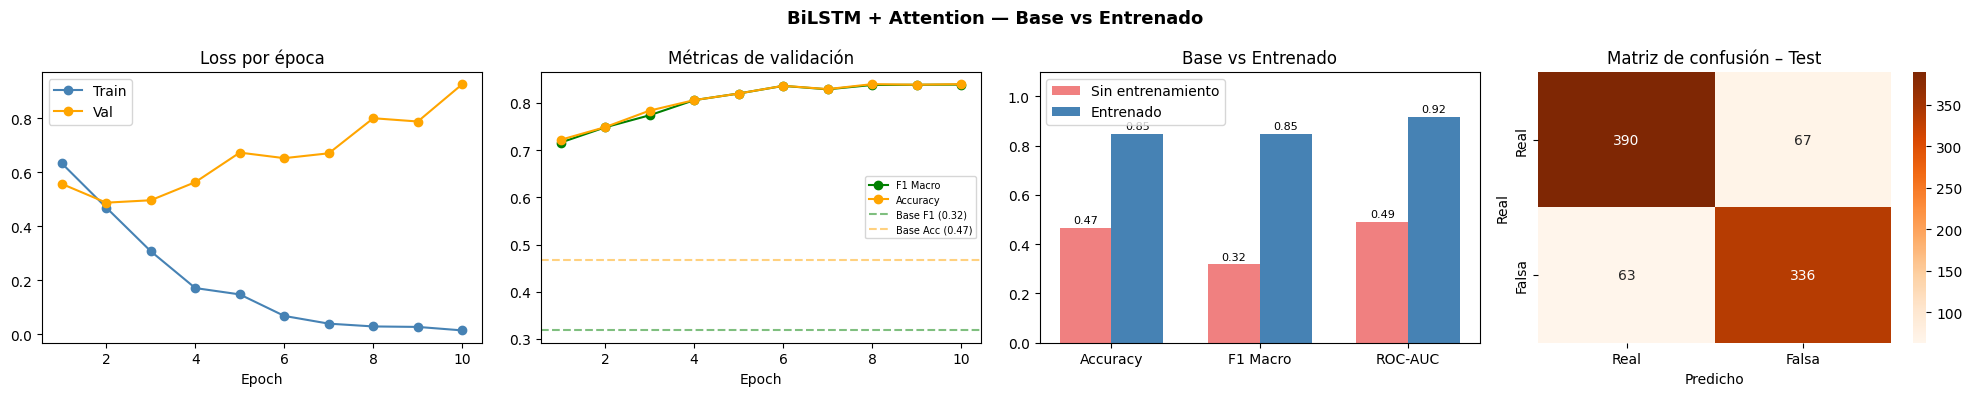

In [5]:
# ═══════════════════════════════════════════════════════════════════════════════
# BiLSTM + Bahdanau Attention — Base vs Fine-tuned
# Sin pre-entrenamiento — aprende desde cero con el dataset
# ═══════════════════════════════════════════════════════════════════════════════

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MAX_LEN    = 256
BATCH_SIZE = 32
EPOCHS     = 10
LR         = 1e-3
EMBED_DIM  = 300
HIDDEN_DIM = 256
N_LAYERS   = 2
DROPOUT    = 0.3
VOCAB_SIZE = 30000

print(f"Dispositivo: {DEVICE}")

# ─── 1. Vocabulario ───────────────────────────────────────────────────────────
print("\nConstruyendo vocabulario...")
all_words  = []
for text in X_train:
    all_words.extend(text.lower().split())

word_counts = Counter(all_words)
vocab       = ["<PAD>", "<UNK>"] + [w for w, _ in word_counts.most_common(VOCAB_SIZE - 2)]
word2idx    = {w: i for i, w in enumerate(vocab)}
print(f"  Vocabulario: {len(vocab):,} palabras")

# ─── 2. Dataset ───────────────────────────────────────────────────────────────
def encode(text, word2idx, max_len):
    tokens = text.lower().split()[:max_len]
    ids    = [word2idx.get(t, 1) for t in tokens]
    ids   += [0] * (max_len - len(ids))
    return ids

class BiLSTMDataset(Dataset):
    def __init__(self, texts, labels):
        self.X = torch.tensor([encode(t, word2idx, MAX_LEN) for t in texts], dtype=torch.long)
        self.y = torch.tensor(list(labels), dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds_bl = BiLSTMDataset(X_train, y_train)
val_ds_bl   = BiLSTMDataset(X_val,   y_val)
test_ds_bl  = BiLSTMDataset(X_test,  y_test)

train_dl_bl = DataLoader(train_ds_bl, batch_size=BATCH_SIZE, shuffle=True)
val_dl_bl   = DataLoader(val_ds_bl,   batch_size=BATCH_SIZE)
test_dl_bl  = DataLoader(test_ds_bl,  batch_size=BATCH_SIZE)

print(f"  Train batches: {len(train_dl_bl)}")
print(f"  Val   batches: {len(val_dl_bl)}")
print(f"  Test  batches: {len(test_dl_bl)}")

# ─── 3. Arquitectura ──────────────────────────────────────────────────────────
class BahdanauAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.W = nn.Linear(hidden_dim * 2, hidden_dim)
        self.v = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, lstm_out):
        energy  = torch.tanh(self.W(lstm_out))
        weights = torch.softmax(self.v(energy), dim=1)
        context = (weights * lstm_out).sum(dim=1)
        return context, weights.squeeze(-1)

class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, n_layers, dropout):
        super().__init__()
        self.embedding  = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm       = nn.LSTM(
            embed_dim, hidden_dim,
            num_layers=n_layers,
            bidirectional=True,
            batch_first=True,
            dropout=dropout if n_layers > 1 else 0,
        )
        self.attention  = BahdanauAttention(hidden_dim)
        self.dropout    = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim * 2, 2)

    def forward(self, x):
        emb              = self.dropout(self.embedding(x))
        out, _           = self.lstm(emb)
        context, weights = self.attention(out)
        logits           = self.classifier(self.dropout(context))
        return logits, weights

# ─── 4. Función de evaluación ─────────────────────────────────────────────────
criterion_bl = nn.CrossEntropyLoss()

def evaluate_bilstm(model, loader):
    model.eval()
    all_preds, all_probs, all_labels = [], [], []
    total_loss = 0
    with torch.no_grad():
        for X_b, y_b in loader:
            X_b, y_b  = X_b.to(DEVICE), y_b.to(DEVICE)
            logits, _ = model(X_b)
            loss       = criterion_bl(logits, y_b)
            total_loss += loss.item()
            probs  = torch.softmax(logits, dim=1)[:, 1]
            preds  = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(y_b.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc  = accuracy_score(all_labels, all_preds)
    f1   = f1_score(all_labels, all_preds, average="macro")
    auc  = roc_auc_score(all_labels, all_probs)
    return avg_loss, acc, f1, auc, all_preds, all_probs, all_labels

# ─── 5. Instanciar modelo ─────────────────────────────────────────────────────
model_bilstm = BiLSTMClassifier(
    vocab_size=len(vocab),
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    n_layers=N_LAYERS,
    dropout=DROPOUT,
).to(DEVICE)

total_params = sum(p.numel() for p in model_bilstm.parameters())
print(f"\n  Parámetros totales: {total_params:,}")

# ─── 6. ACCURACY BASE (sin entrenamiento) ────────────────────────────────────
print("\n" + "═" * 60)
print("ACCURACY BASE – BiLSTM SIN entrenamiento")
print("═" * 60)

_, base_acc_bl, base_f1_bl, base_auc_bl, _, _, _ = evaluate_bilstm(model_bilstm, test_dl_bl)
print(f"  Accuracy  : {base_acc_bl:.4f}  ({base_acc_bl*100:.1f}%)")
print(f"  F1 Macro  : {base_f1_bl:.4f}")
print(f"  ROC-AUC   : {base_auc_bl:.4f}")
print(f"  → Referencia para medir la mejora del entrenamiento")

# ─── 7. Entrenamiento ─────────────────────────────────────────────────────────
optimizer_bl = AdamW(model_bilstm.parameters(), lr=LR, weight_decay=1e-4)
scheduler_bl = ReduceLROnPlateau(optimizer_bl, mode="max", patience=2, factor=0.5)

history_bilstm = {"train_loss": [], "val_loss": [], "val_acc": [], "val_f1": [], "val_auc": []}
best_val_f1    = 0
patience_count = 0
PATIENCE       = 3

print("\n" + "═" * 60)
print("ENTRENAMIENTO BiLSTM + Attention")
print("═" * 60)

for epoch in range(1, EPOCHS + 1):
    model_bilstm.train()
    total_train_loss = 0

    loop = tqdm(train_dl_bl, desc=f"Epoch {epoch}/{EPOCHS}")
    for X_b, y_b in loop:
        X_b, y_b  = X_b.to(DEVICE), y_b.to(DEVICE)
        optimizer_bl.zero_grad()
        logits, _ = model_bilstm(X_b)
        loss       = criterion_bl(logits, y_b)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_bilstm.parameters(), 1.0)
        optimizer_bl.step()
        total_train_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    avg_train_loss = total_train_loss / len(train_dl_bl)
    val_loss, val_acc, val_f1, val_auc, _, _, _ = evaluate_bilstm(model_bilstm, val_dl_bl)
    scheduler_bl.step(val_f1)

    history_bilstm["train_loss"].append(avg_train_loss)
    history_bilstm["val_loss"].append(val_loss)
    history_bilstm["val_acc"].append(val_acc)
    history_bilstm["val_f1"].append(val_f1)
    history_bilstm["val_auc"].append(val_auc)

    print(f"\nEpoch {epoch} │ train_loss: {avg_train_loss:.4f} │ "
          f"val_loss: {val_loss:.4f} │ val_acc: {val_acc:.4f} │ "
          f"val_f1: {val_f1:.4f} │ val_auc: {val_auc:.4f}")

    if val_f1 > best_val_f1:
        best_val_f1    = val_f1
        torch.save(model_bilstm.state_dict(), "bilstm_best.pt")
        print(f"  ✅ Mejor modelo guardado (val_f1={best_val_f1:.4f})")
        patience_count = 0
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print(f"  ⏹ Early stopping en epoch {epoch}")
            break

# ─── 8. Evaluación final en TEST ─────────────────────────────────────────────
print("\n" + "═" * 60)
print("EVALUACIÓN FINAL BiLSTM – TEST SET")
print("═" * 60)

model_bilstm.load_state_dict(torch.load("bilstm_best.pt"))
_, test_acc_bl, test_f1_bl, test_auc_bl, test_preds_bl, test_probs_bl, test_labels_bl = evaluate_bilstm(model_bilstm, test_dl_bl)

print(f"  Accuracy base (sin FT) : {base_acc_bl:.4f}  ({base_acc_bl*100:.1f}%)")
print(f"  Accuracy entrenado     : {test_acc_bl:.4f}  ({test_acc_bl*100:.1f}%)")
print(f"  Mejora                 : +{(test_acc_bl - base_acc_bl)*100:.1f} puntos porcentuales")
print(f"  ─────────────────────────────────────────────────────")
print(f"  F1 Macro  : {test_f1_bl:.4f}")
print(f"  ROC-AUC   : {test_auc_bl:.4f}")

bilstm_results = {
    "name":     "BiLSTM + Attention",
    "acc":      test_acc_bl,
    "f1":       test_f1_bl,
    "auc":      test_auc_bl,
    "preds":    test_preds_bl,
    "probs":    test_probs_bl,
    "labels":   test_labels_bl,
    "history":  history_bilstm,
    "base_acc": base_acc_bl,
    "base_f1":  base_f1_bl,
    "base_auc": base_auc_bl,
    "model":    model_bilstm,
    "word2idx": word2idx,
    "vocab":    vocab,
}

# ─── 9. Gráficas: Base vs Entrenado ──────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
fig.suptitle("BiLSTM + Attention — Base vs Entrenado", fontsize=13, fontweight="bold")

epochs_ran = range(1, len(history_bilstm["train_loss"]) + 1)

# Loss
axes[0].plot(epochs_ran, history_bilstm["train_loss"], label="Train", marker="o", color="steelblue")
axes[0].plot(epochs_ran, history_bilstm["val_loss"],   label="Val",   marker="o", color="orange")
axes[0].set_title("Loss por época")
axes[0].set_xlabel("Epoch")
axes[0].legend()

# F1 y Accuracy con línea base
axes[1].plot(epochs_ran, history_bilstm["val_f1"],  label="F1 Macro", marker="o", color="green")
axes[1].plot(epochs_ran, history_bilstm["val_acc"], label="Accuracy", marker="o", color="orange")
axes[1].axhline(y=base_f1_bl,  color="green",  linestyle="--", alpha=0.5, label=f"Base F1 ({base_f1_bl:.2f})")
axes[1].axhline(y=base_acc_bl, color="orange", linestyle="--", alpha=0.5, label=f"Base Acc ({base_acc_bl:.2f})")
axes[1].set_title("Métricas de validación")
axes[1].set_xlabel("Epoch")
axes[1].legend(fontsize=7)

# Barras comparativas Base vs Entrenado
metricas  = ["Accuracy", "F1 Macro", "ROC-AUC"]
base_vals = [base_acc_bl, base_f1_bl, base_auc_bl]
ft_vals   = [test_acc_bl, test_f1_bl, test_auc_bl]
x         = range(len(metricas))
width     = 0.35

axes[2].bar([i - width/2 for i in x], base_vals, width, label="Sin entrenamiento", color="lightcoral")
axes[2].bar([i + width/2 for i in x], ft_vals,   width, label="Entrenado",         color="steelblue")
axes[2].set_xticks(list(x))
axes[2].set_xticklabels(metricas)
axes[2].set_ylim(0, 1.1)
axes[2].set_title("Base vs Entrenado")
axes[2].legend()
for i, (b, f) in enumerate(zip(base_vals, ft_vals)):
    axes[2].text(i - width/2, b + 0.02, f"{b:.2f}", ha="center", fontsize=8)
    axes[2].text(i + width/2, f + 0.02, f"{f:.2f}", ha="center", fontsize=8)

# Matriz de confusión
cm = confusion_matrix(test_labels_bl, test_preds_bl)
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges",
            xticklabels=["Real","Falsa"],
            yticklabels=["Real","Falsa"], ax=axes[3])
axes[3].set_title("Matriz de confusión – Test")
axes[3].set_ylabel("Real")
axes[3].set_xlabel("Predicho")

plt.tight_layout()
plt.show()

═════════════════════════════════════════════════════════════════
Modelo                        Base      Acc       F1      AUC   Mejora
═════════════════════════════════════════════════════════════════
  BiLSTM + Attention         46.6%    84.8%   0.8475   0.9157   +38.2pts
  BETO (Baseline)            50.2%    90.2%   0.9013   0.9631   +40.0pts
  RoBERTa-es (Mejora)        53.2%    90.9%   0.9078   0.9472   +37.7pts
═════════════════════════════════════════════════════════════════


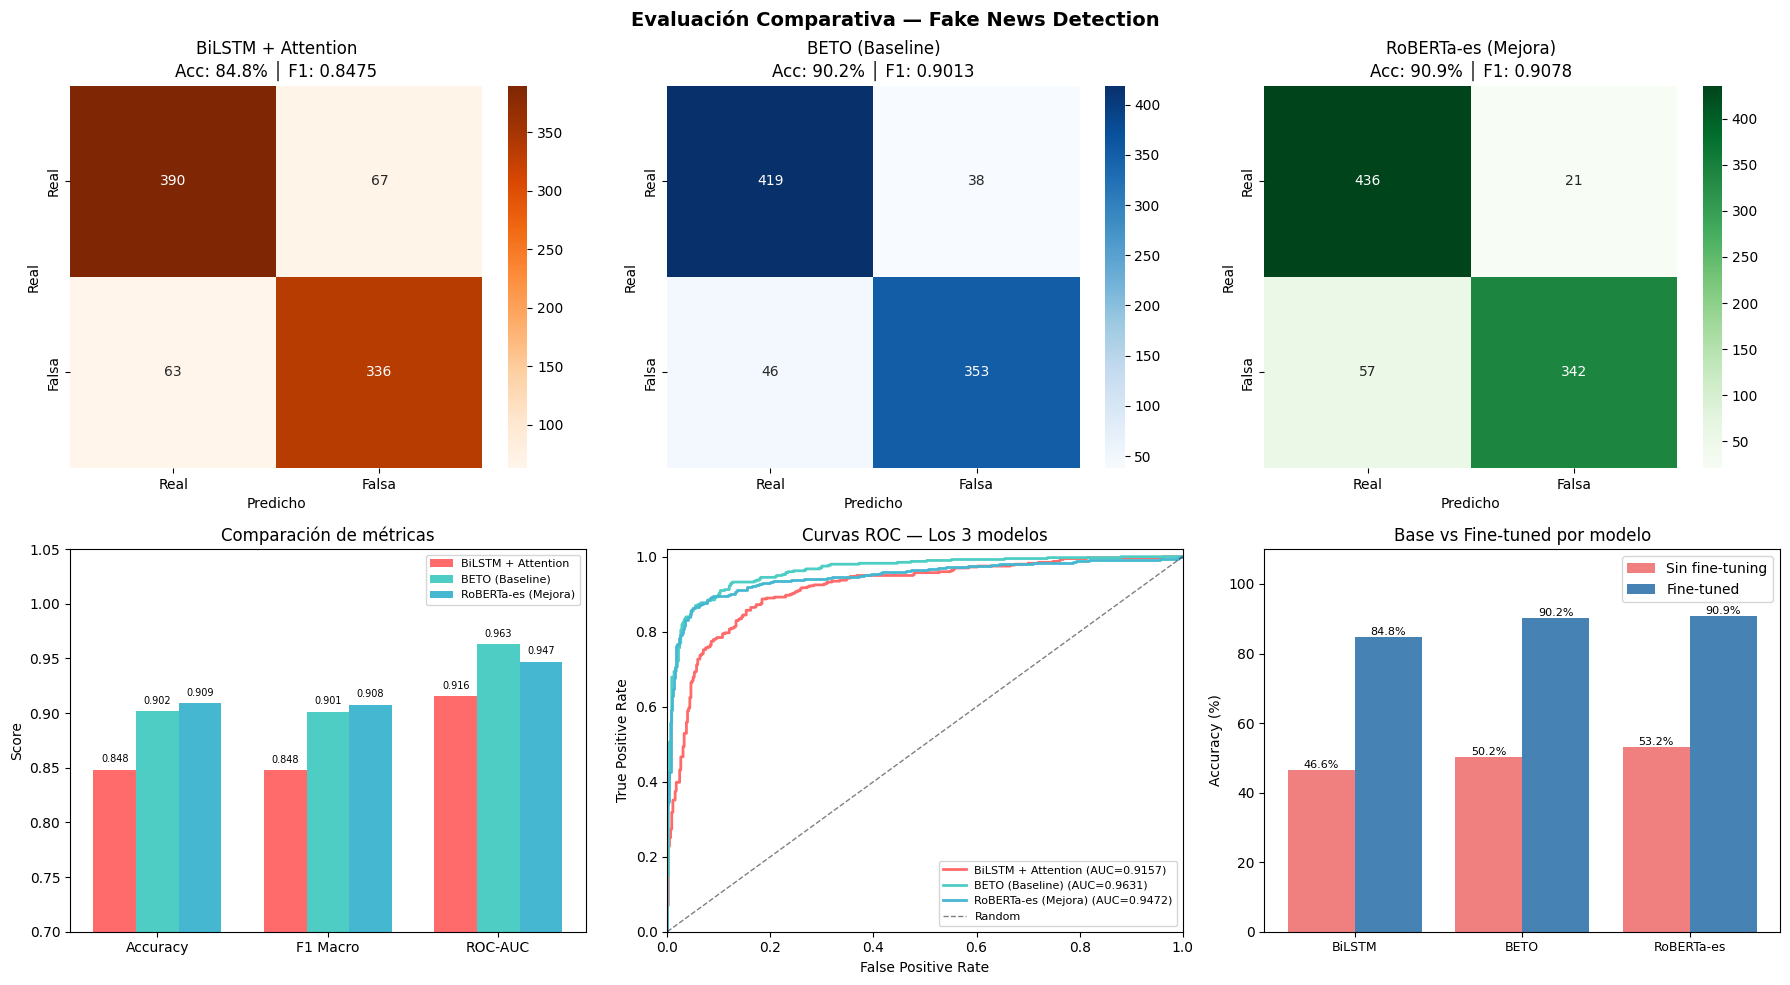

In [6]:
# ═══════════════════════════════════════════════════════════════════════════════
# EVALUACIÓN COMPARATIVA FINAL – Los 3 modelos
# ═══════════════════════════════════════════════════════════════════════════════

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc

MODELOS = [bilstm_results, beto_results, roberta_results]
COLORES = ["#FF6B6B", "#4ECDC4", "#45B7D1"]

# ─── 1. Tabla comparativa ─────────────────────────────────────────────────────
print("═" * 65)
print(f"{'Modelo':<25} {'Base':>8} {'Acc':>8} {'F1':>8} {'AUC':>8} {'Mejora':>8}")
print("═" * 65)
for m in MODELOS:
    mejora = (m['acc'] - m['base_acc']) * 100
    print(f"  {m['name']:<23} {m['base_acc']*100:>7.1f}% {m['acc']*100:>7.1f}% "
          f"{m['f1']:>8.4f} {m['auc']:>8.4f} {mejora:>+7.1f}pts")
print("═" * 65)

# ─── 2. Gráficas ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Evaluación Comparativa — Fake News Detection", fontsize=14, fontweight="bold")

# ── Fila 1: Matrices de confusión ─────────────────────────────────────────────
cmaps = ["Oranges", "Blues", "Greens"]
for idx, (m, cmap) in enumerate(zip(MODELOS, cmaps)):
    cm = confusion_matrix(m["labels"], m["preds"])
    sns.heatmap(
        cm, annot=True, fmt="d", cmap=cmap,
        xticklabels=["Real","Falsa"],
        yticklabels=["Real","Falsa"],
        ax=axes[0][idx],
    )
    axes[0][idx].set_title(f"{m['name']}\nAcc: {m['acc']*100:.1f}% │ F1: {m['f1']:.4f}")
    axes[0][idx].set_ylabel("Real")
    axes[0][idx].set_xlabel("Predicho")

# ── Fila 2 col 0: Barras comparativas Acc / F1 / AUC ─────────────────────────
metricas   = ["Accuracy", "F1 Macro", "ROC-AUC"]
x          = np.arange(len(metricas))
width      = 0.25

for idx, (m, color) in enumerate(zip(MODELOS, COLORES)):
    vals = [m["acc"], m["f1"], m["auc"]]
    bars = axes[1][0].bar(x + idx * width, vals, width, label=m["name"], color=color)
    for bar, val in zip(bars, vals):
        axes[1][0].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f"{val:.3f}", ha="center", va="bottom", fontsize=7
        )

axes[1][0].set_xticks(x + width)
axes[1][0].set_xticklabels(metricas)
axes[1][0].set_ylim(0.7, 1.05)
axes[1][0].set_title("Comparación de métricas")
axes[1][0].legend(fontsize=8)
axes[1][0].set_ylabel("Score")

# ── Fila 2 col 1: Curvas ROC ──────────────────────────────────────────────────
for m, color in zip(MODELOS, COLORES):
    fpr, tpr, _ = roc_curve(m["labels"], m["probs"])
    roc_auc     = auc(fpr, tpr)
    axes[1][1].plot(fpr, tpr, color=color, lw=2,
                    label=f"{m['name']} (AUC={roc_auc:.4f})")

axes[1][1].plot([0,1], [0,1], "k--", lw=1, alpha=0.5, label="Random")
axes[1][1].set_xlim([0, 1])
axes[1][1].set_ylim([0, 1.02])
axes[1][1].set_xlabel("False Positive Rate")
axes[1][1].set_ylabel("True Positive Rate")
axes[1][1].set_title("Curvas ROC — Los 3 modelos")
axes[1][1].legend(fontsize=8)

# ── Fila 2 col 2: Base vs Fine-tuned por modelo ───────────────────────────────
nombres   = [m["name"].split(" ")[0] for m in MODELOS]
base_accs = [m["base_acc"] * 100 for m in MODELOS]
ft_accs   = [m["acc"] * 100 for m in MODELOS]
x2        = np.arange(len(nombres))

axes[1][2].bar(x2 - 0.2, base_accs, 0.4, label="Sin fine-tuning", color="lightcoral")
axes[1][2].bar(x2 + 0.2, ft_accs,   0.4, label="Fine-tuned",      color="steelblue")
for i, (b, f) in enumerate(zip(base_accs, ft_accs)):
    axes[1][2].text(i - 0.2, b + 0.5, f"{b:.1f}%", ha="center", fontsize=8)
    axes[1][2].text(i + 0.2, f + 0.5, f"{f:.1f}%", ha="center", fontsize=8)

axes[1][2].set_xticks(x2)
axes[1][2].set_xticklabels(nombres, fontsize=9)
axes[1][2].set_ylim(0, 110)
axes[1][2].set_title("Base vs Fine-tuned por modelo")
axes[1][2].set_ylabel("Accuracy (%)")
axes[1][2].legend()

plt.tight_layout()
plt.show()

## Evaluacion externa con noticias nuevas

Esta seccion permite revisar si los modelos generalizan fuera del dataset original. Usa un archivo `data/external/noticias_externas.csv` con columnas `title`, `text` y, opcionalmente, `label`, `source`, `url`, `date`. La etiqueta opcional mantiene la convencion del proyecto: `0 = real`, `1 = falsa`.

Si `label` esta vacia, la celda muestra predicciones y confianza, pero no calcula metricas. Si `label` viene diligenciada, calcula accuracy, F1, AUC, matrices de confusion y un resumen por fuente externa.


In [ ]:
# =============================================================================
# GUARDAR ARTEFACTOS ENTRENADOS
# Ejecutar despues de entrenar BETO, RoBERTa-es y BiLSTM.
# =============================================================================
from pathlib import Path
import json
import torch

ARTIFACT_DIR = Path("artifacts")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

saved = []
missing = []

# BETO: guarda modelo y tokenizer ya fine-tuned.
if "model_beto" in globals() and "tokenizer" in globals():
    beto_dir = ARTIFACT_DIR / "beto"
    beto_dir.mkdir(exist_ok=True)
    model_beto.save_pretrained(beto_dir)
    tokenizer.save_pretrained(beto_dir)
    saved.append(str(beto_dir))
else:
    missing.append("BETO: ejecuta primero la celda de entrenamiento BETO")

# RoBERTa-es: guarda modelo y tokenizer ya fine-tuned.
if "model_roberta" in globals() and "tokenizer_roberta" in globals():
    roberta_dir = ARTIFACT_DIR / "roberta_es"
    roberta_dir.mkdir(exist_ok=True)
    model_roberta.save_pretrained(roberta_dir)
    tokenizer_roberta.save_pretrained(roberta_dir)
    saved.append(str(roberta_dir))
else:
    missing.append("RoBERTa-es: ejecuta primero la celda de entrenamiento RoBERTa")

# BiLSTM: guarda pesos, vocabulario e hiperparametros necesarios para inferencia.
if "model_bilstm" in globals() and "word2idx" in globals() and "vocab" in globals():
    bilstm_path = ARTIFACT_DIR / "bilstm_attention.pt"
    torch.save(
        {
            "model_state_dict": model_bilstm.state_dict(),
            "word2idx": word2idx,
            "vocab": vocab,
            "max_len": MAX_LEN,
            "embed_dim": EMBED_DIM,
            "hidden_dim": HIDDEN_DIM,
            "n_layers": N_LAYERS,
            "dropout": DROPOUT,
        },
        bilstm_path,
    )
    saved.append(str(bilstm_path))
else:
    missing.append("BiLSTM: ejecuta primero la celda de entrenamiento BiLSTM")

summary_path = ARTIFACT_DIR / "README_artifacts.json"
summary_path.write_text(
    json.dumps(
        {
            "label_mapping": {"0": "real", "1": "falsa"},
            "text_input": "title + [SEP] + text",
            "max_len": 256,
            "saved": saved,
            "missing": missing,
        },
        indent=2,
        ensure_ascii=False,
    ),
    encoding="utf-8",
)

print("Artefactos guardados:")
for item in saved:
    print(" -", item)

if missing:
    print("\nPendiente:")
    for item in missing:
        print(" -", item)


In [ ]:
# =============================================================================
# EVALUACION EXTERNA: noticias nuevas fuera del dataset original
# =============================================================================
from pathlib import Path
import re
import unicodedata
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

try:
    from IPython.display import display
except ImportError:
    display = print

EXTERNAL_CSV_PATH = Path("data/external/noticias_externas.csv")
EXTERNAL_COLUMNS = ["title", "text", "label", "source", "url", "date"]
LABEL_MAP = {
    "0": 0, "real": 0, "true": 0, "verdadera": 0, "veridica": 0,
    "1": 1, "falsa": 1, "fake": 1, "false": 1,
}
CONFIDENCE_REVIEW_THRESHOLD = 0.65

# Tambien puedes pegar noticias manualmente aqui si no quieres usar CSV.
# Ejemplo de fila:
# {"title": "...", "text": "...", "label": 0, "source": "medio externo", "url": "https://...", "date": "2026-05-19"}
EXTERNAL_NEWS = []


def clean_external_text(text):
    text = unicodedata.normalize("NFC", str(text))
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#\w+", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def normalize_external_label(value):
    if pd.isna(value) or str(value).strip() == "":
        return np.nan
    key = str(value).strip().lower()
    if key in LABEL_MAP:
        return LABEL_MAP[key]
    try:
        as_int = int(float(key))
        return as_int if as_int in (0, 1) else np.nan
    except ValueError:
        return np.nan


def load_external_news():
    if EXTERNAL_CSV_PATH.exists():
        external = pd.read_csv(EXTERNAL_CSV_PATH)
        print(f"Cargadas {len(external)} noticias externas desde {EXTERNAL_CSV_PATH}")
    elif EXTERNAL_NEWS:
        external = pd.DataFrame(EXTERNAL_NEWS)
        print(f"Cargadas {len(external)} noticias externas desde EXTERNAL_NEWS")
    else:
        EXTERNAL_CSV_PATH.parent.mkdir(parents=True, exist_ok=True)
        pd.DataFrame(columns=EXTERNAL_COLUMNS).to_csv(EXTERNAL_CSV_PATH, index=False, encoding="utf-8-sig")
        print("No se encontraron noticias externas.")
        print(f"Se creo una plantilla en: {EXTERNAL_CSV_PATH}")
        print("Llena al menos las columnas title y text. La columna label es opcional: 0=real, 1=falsa.")
        return pd.DataFrame(columns=EXTERNAL_COLUMNS)

    for col in EXTERNAL_COLUMNS:
        if col not in external.columns:
            external[col] = np.nan

    external = external.dropna(subset=["text"]).copy()
    external["title"] = external["title"].fillna("").map(clean_external_text)
    external["text"] = external["text"].fillna("").map(clean_external_text)
    external = external[external["text"].str.len() >= 30].copy()
    external["label"] = external["label"].map(normalize_external_label)
    external["source"] = external["source"].fillna("externa")
    external["combined"] = external["title"] + " [SEP] " + external["text"]
    external = external.drop_duplicates(subset=["text"]).reset_index(drop=True)

    if "df" in globals() and "text" in df.columns:
        overlap = external["text"].isin(set(df["text"].astype(str)))
        if overlap.any():
            print(f"Advertencia: {overlap.sum()} textos externos ya existen en el dataset original. Revisa posible fuga de datos.")

    return external


@torch.no_grad()
def predict_transformer_external(model, tokenizer_obj, texts, batch_size=16, max_len=256):
    model.eval()
    model.to(DEVICE)
    probs_fake = []

    for start in range(0, len(texts), batch_size):
        batch_texts = list(texts[start:start + batch_size])
        enc = tokenizer_obj(
            batch_texts,
            max_length=max_len,
            padding=True,
            truncation=True,
            return_tensors="pt",
        )
        enc = {k: v.to(DEVICE) for k, v in enc.items() if k in ["input_ids", "attention_mask", "token_type_ids"]}
        outputs = model(**enc)
        probs = torch.softmax(outputs.logits, dim=1)[:, 1]
        probs_fake.extend(probs.detach().cpu().numpy())

    probs_fake = np.array(probs_fake)
    preds = (probs_fake >= 0.5).astype(int)
    confidence = np.maximum(probs_fake, 1 - probs_fake)
    return preds, probs_fake, confidence


def encode_bilstm_external(text, word2idx_obj, max_len):
    tokens = str(text).lower().split()[:max_len]
    ids = [word2idx_obj.get(token, 1) for token in tokens]
    ids += [0] * (max_len - len(ids))
    return ids


@torch.no_grad()
def predict_bilstm_external(model, texts, word2idx_obj, batch_size=32, max_len=256):
    model.eval()
    model.to(DEVICE)
    probs_fake = []

    encoded = torch.tensor(
        [encode_bilstm_external(text, word2idx_obj, max_len) for text in texts],
        dtype=torch.long,
    )

    for start in range(0, len(encoded), batch_size):
        batch = encoded[start:start + batch_size].to(DEVICE)
        logits, _ = model(batch)
        probs = torch.softmax(logits, dim=1)[:, 1]
        probs_fake.extend(probs.detach().cpu().numpy())

    probs_fake = np.array(probs_fake)
    preds = (probs_fake >= 0.5).astype(int)
    confidence = np.maximum(probs_fake, 1 - probs_fake)
    return preds, probs_fake, confidence


def add_model_predictions(output_df, model_name, preds, probs, confidence):
    prefix = model_name.lower().replace(" ", "_").replace("-", "_")
    output_df[f"{prefix}_pred"] = preds
    output_df[f"{prefix}_p_falsa"] = probs
    output_df[f"{prefix}_confianza"] = confidence
    output_df[f"{prefix}_clase"] = np.where(preds == 1, "falsa", "real")
    return output_df


def metric_row(name, y_true, y_pred, probs):
    row = {
        "modelo": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, average="macro"),
    }
    row["roc_auc"] = roc_auc_score(y_true, probs) if len(np.unique(y_true)) == 2 else np.nan
    return row


external_df = load_external_news()

if external_df.empty:
    external_eval = pd.DataFrame()
else:
    required_objects = {
        "BETO": ["model_beto", "tokenizer"],
        "RoBERTa-es": ["model_roberta", "tokenizer_roberta"],
        "BiLSTM": ["model_bilstm", "word2idx"],
    }
    missing_models = []
    for name, objects in required_objects.items():
        missing = [obj for obj in objects if obj not in globals()]
        if missing:
            missing_models.append(f"{name}: falta {', '.join(missing)}")

    if missing_models:
        print("No se puede evaluar aun. Ejecuta antes las celdas de entrenamiento o carga los artefactos.")
        for item in missing_models:
            print(" -", item)
        external_eval = pd.DataFrame()
    else:
        texts = external_df["combined"].tolist()
        external_eval = external_df.copy()

        beto_pred, beto_prob, beto_conf = predict_transformer_external(model_beto, tokenizer, texts, batch_size=16, max_len=256)
        external_eval = add_model_predictions(external_eval, "BETO", beto_pred, beto_prob, beto_conf)

        roberta_pred, roberta_prob, roberta_conf = predict_transformer_external(model_roberta, tokenizer_roberta, texts, batch_size=16, max_len=256)
        external_eval = add_model_predictions(external_eval, "RoBERTa_es", roberta_pred, roberta_prob, roberta_conf)

        bilstm_pred, bilstm_prob, bilstm_conf = predict_bilstm_external(model_bilstm, texts, word2idx, batch_size=32, max_len=256)
        external_eval = add_model_predictions(external_eval, "BiLSTM", bilstm_pred, bilstm_prob, bilstm_conf)

        model_prob_cols = ["beto_p_falsa", "roberta_es_p_falsa", "bilstm_p_falsa"]
        model_pred_cols = ["beto_pred", "roberta_es_pred", "bilstm_pred"]
        model_conf_cols = ["beto_confianza", "roberta_es_confianza", "bilstm_confianza"]

        external_eval["ensemble_p_falsa"] = external_eval[model_prob_cols].mean(axis=1)
        external_eval["ensemble_pred"] = (external_eval["ensemble_p_falsa"] >= 0.5).astype(int)
        external_eval["ensemble_clase"] = np.where(external_eval["ensemble_pred"] == 1, "falsa", "real")
        external_eval["ensemble_confianza"] = np.maximum(external_eval["ensemble_p_falsa"], 1 - external_eval["ensemble_p_falsa"])
        external_eval["desacuerdo_modelos"] = external_eval[model_pred_cols].nunique(axis=1) > 1
        external_eval["requiere_revision"] = (
            external_eval["desacuerdo_modelos"]
            | (external_eval[model_conf_cols].min(axis=1) < CONFIDENCE_REVIEW_THRESHOLD)
            | (external_eval["ensemble_confianza"] < CONFIDENCE_REVIEW_THRESHOLD)
        )

        print(f"Noticias externas evaluadas: {len(external_eval)}")
        display_cols = [
            "title", "source", "label",
            "beto_clase", "beto_p_falsa", "beto_confianza",
            "roberta_es_clase", "roberta_es_p_falsa", "roberta_es_confianza",
            "bilstm_clase", "bilstm_p_falsa", "bilstm_confianza",
            "ensemble_clase", "ensemble_p_falsa", "ensemble_confianza",
            "desacuerdo_modelos", "requiere_revision",
        ]
        display(external_eval[display_cols].sort_values(["requiere_revision", "ensemble_confianza"], ascending=[False, True]))

        labeled = external_eval.dropna(subset=["label"]).copy()
        if labeled.empty:
            print("\nNo hay etiquetas externas. Se muestran predicciones, pero no se calculan metricas.")
        else:
            labeled["label"] = labeled["label"].astype(int)
            metrics = [
                metric_row("BETO", labeled["label"], labeled["beto_pred"], labeled["beto_p_falsa"]),
                metric_row("RoBERTa-es", labeled["label"], labeled["roberta_es_pred"], labeled["roberta_es_p_falsa"]),
                metric_row("BiLSTM", labeled["label"], labeled["bilstm_pred"], labeled["bilstm_p_falsa"]),
                metric_row("Ensemble promedio", labeled["label"], labeled["ensemble_pred"], labeled["ensemble_p_falsa"]),
            ]
            metrics_df = pd.DataFrame(metrics)
            print("\nMetricas en noticias externas etiquetadas:")
            display(metrics_df)

            print("\nMatrices de confusion externas (filas=real, columnas=predicho):")
            for name, pred_col in [
                ("BETO", "beto_pred"),
                ("RoBERTa-es", "roberta_es_pred"),
                ("BiLSTM", "bilstm_pred"),
                ("Ensemble", "ensemble_pred"),
            ]:
                cm = confusion_matrix(labeled["label"], labeled[pred_col], labels=[0, 1])
                print(f"\n{name}")
                print(pd.DataFrame(cm, index=["real_0", "falsa_1"], columns=["pred_real_0", "pred_falsa_1"]))

            by_source_rows = []
            for source, group in labeled.groupby("source"):
                if len(group) < 2:
                    continue
                by_source_rows.append(
                    {
                        "source": source,
                        "n": len(group),
                        "real": int((group["label"] == 0).sum()),
                        "falsa": int((group["label"] == 1).sum()),
                        "ensemble_accuracy": accuracy_score(group["label"], group["ensemble_pred"]),
                        "revision_rate": group["requiere_revision"].mean(),
                    }
                )
            if by_source_rows:
                print("\nResumen por fuente externa:")
                display(pd.DataFrame(by_source_rows).sort_values("ensemble_accuracy"))

            errors = labeled[labeled["label"] != labeled["ensemble_pred"]].copy()
            if not errors.empty:
                print("\nErrores del ensemble para revision manual:")
                display(errors[["title", "source", "label", "ensemble_clase", "ensemble_p_falsa", "ensemble_confianza", "text"]])

        print("\nNota: estas predicciones no verifican hechos. Miden similitud estadistica con los patrones aprendidos del corpus de entrenamiento.")
